In [1]:
import pandas as pd
import numpy as np
import streamlit as st
import plotly.express as px

# Load data
car_data = pd.read_csv('vehicles_us.csv')



In [2]:
# Display raw data
print("Vehicle Data Preprocessing")
print("Raw Data")
print(car_data.head())

Vehicle Data Preprocessing
Raw Data
   price  model_year           model  condition  cylinders fuel  odometer  \
0   9400      2011.0          bmw x5       good        6.0  gas  145000.0   
1  25500         NaN      ford f-150       good        6.0  gas   88705.0   
2   5500      2013.0  hyundai sonata   like new        4.0  gas  110000.0   
3   1500      2003.0      ford f-150       fair        8.0  gas       NaN   
4  14900      2017.0    chrysler 200  excellent        4.0  gas   80903.0   

  transmission    type paint_color  is_4wd date_posted  days_listed  
0    automatic     SUV         NaN     1.0  2018-06-23           19  
1    automatic  pickup       white     1.0  2018-10-19           50  
2    automatic   sedan         red     NaN  2019-02-07           79  
3    automatic  pickup         NaN     NaN  2019-03-22            9  
4    automatic   sedan       black     NaN  2019-04-02           28  


In [4]:
# Check for missing values
print("Missing Values")
missing = car_data.isnull().sum()
print(missing[missing > 0])

Missing Values
model_year      3619
cylinders       5260
odometer        7892
paint_color     9267
is_4wd         25953
dtype: int64


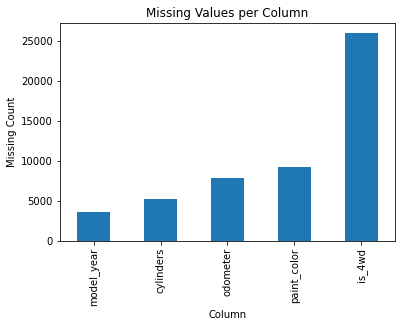

In [5]:
# Visualize missing values
import matplotlib.pyplot as plt
missing[missing > 0].plot(kind='bar', title="Missing Values per Column")
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.show()

In [6]:
# Handle missing values using the sum of NaNs in each column (fill with the count of NaNs)
for col in car_data.columns:
    if car_data[col].isnull().sum() > 0:
        car_data[col] = car_data[col].fillna(car_data[col].isnull().sum())

In [ ]:
# Check for duplicates
print("Duplicate Rows")
duplicates = car_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
car_data = car_data.drop_duplicates()



Duplicate Rows
Number of duplicate rows: 0


In [8]:
# Display cleaned data
print("Cleaned Data")
print(car_data.head())

Cleaned Data
   price  model_year           model  condition  cylinders fuel  odometer  \
0   9400      2011.0          bmw x5       good        6.0  gas  145000.0   
1  25500      3619.0      ford f-150       good        6.0  gas   88705.0   
2   5500      2013.0  hyundai sonata   like new        4.0  gas  110000.0   
3   1500      2003.0      ford f-150       fair        8.0  gas    7892.0   
4  14900      2017.0    chrysler 200  excellent        4.0  gas   80903.0   

  transmission    type paint_color   is_4wd date_posted  days_listed  
0    automatic     SUV        9267      1.0  2018-06-23           19  
1    automatic  pickup       white      1.0  2018-10-19           50  
2    automatic   sedan         red  25953.0  2019-02-07           79  
3    automatic  pickup        9267  25953.0  2019-03-22            9  
4    automatic   sedan       black  25953.0  2019-04-02           28  


In [9]:
# Data types correction
print("Data Types Correction")
if 'model_year' in car_data.columns:
    car_data['model_year'] = car_data['model_year'].astype(int)
if 'cylinders' in car_data.columns:
    car_data['cylinders'] = car_data['cylinders'].astype(int)
if 'is_4wd' in car_data.columns:
    car_data['is_4wd'] = car_data['is_4wd'].fillna(0).astype(int)

Data Types Correction


In [10]:
# Feature engineering: Age of car
current_year = pd.Timestamp.now().year
if 'model_year' in car_data.columns:
    car_data['age'] = current_year - car_data['model_year']

Outlier Detection


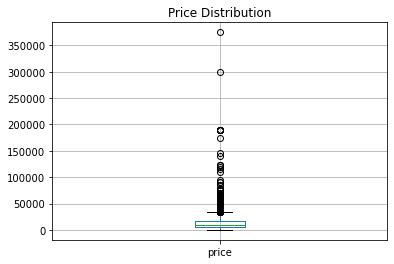

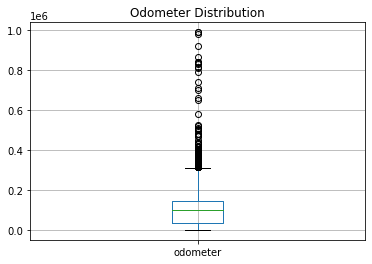

In [11]:
# Outlier detection (example for 'price' and 'odometer')
print("Outlier Detection")
for col in ['price', 'odometer']:
    if col in car_data.columns:
        plt.figure()
        car_data.boxplot(column=col)
        plt.title(f"{col.capitalize()} Distribution")
        plt.show()


In [12]:

# Remove outliers (using IQR)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['price', 'odometer']:
    if col in car_data.columns:
        car_data = remove_outliers(car_data, col)

In [13]:
# Encode categorical variables
print("Encoding Categorical Variables")
categorical_cols = ['type', 'paint_color', 'state', 'manufacturer']
existing_cats = [col for col in categorical_cols if col in car_data.columns]
car_data = pd.get_dummies(car_data, columns=existing_cats, drop_first=True)

Encoding Categorical Variables


In [14]:
# Final dataset preview
print("Preprocessed Data Sample")
print(car_data.head())

Preprocessed Data Sample
   price  model_year           model  condition  cylinders fuel  odometer  \
0   9400        2011          bmw x5       good          6  gas  145000.0   
1  25500        3619      ford f-150       good          6  gas   88705.0   
2   5500        2013  hyundai sonata   like new          4  gas  110000.0   
3   1500        2003      ford f-150       fair          8  gas    7892.0   
4  14900        2017    chrysler 200  excellent          4  gas   80903.0   

  transmission  is_4wd date_posted  ...  paint_color_brown  \
0    automatic       1  2018-06-23  ...                  0   
1    automatic       1  2018-10-19  ...                  0   
2    automatic   25953  2019-02-07  ...                  0   
3    automatic   25953  2019-03-22  ...                  0   
4    automatic   25953  2019-04-02  ...                  0   

   paint_color_custom  paint_color_green  paint_color_grey  \
0                   0                  0                 0   
1              

In [15]:
# Save preprocessed data
car_data.to_csv('vehicles_us_preprocessed.csv', index=False)
print("Preprocessed data saved to vehicles_us_preprocessed.csv")


Preprocessed data saved to vehicles_us_preprocessed.csv


In [16]:
#Displaying columns and data types from the cleaned dataset
print("Columns and Data Types")
print(car_data.dtypes)

Columns and Data Types
price                   int64
model_year              int32
model                  object
condition              object
cylinders               int32
fuel                   object
odometer              float64
transmission           object
is_4wd                  int32
date_posted            object
days_listed             int64
age                     int32
type_bus                uint8
type_convertible        uint8
type_coupe              uint8
type_hatchback          uint8
type_mini-van           uint8
type_offroad            uint8
type_other              uint8
type_pickup             uint8
type_sedan              uint8
type_truck              uint8
type_van                uint8
type_wagon              uint8
paint_color_black       uint8
paint_color_blue        uint8
paint_color_brown       uint8
paint_color_custom      uint8
paint_color_green       uint8
paint_color_grey        uint8
paint_color_orange      uint8
paint_color_purple      uint8
paint_color_red  

## Streamlit app for visualization on the appy.py file


